# **Rep. 4. Checkpoint 3. Estrategias II**

Sara Hernandez y Edgardo Gonzalez

In [7]:
import numpy as np
import yfinance as yf

# Descargar datos de SPY
ticker = yf.Ticker("SPY")

# Precio actual (S0)
S0 = ticker.history(period="1d")["Close"].iloc[-1]

# Opciones con vencimiento 2026-04-17
exp_date = "2026-04-17"
opt = ticker.option_chain(exp_date)

calls = opt.calls
puts = opt.puts

print(f"Precio actual SPY (S0): {S0:.2f}")

Precio actual SPY (S0): 697.11


Strikes cercanos al dinero

In [8]:
# Función para calcular precio mid
def mid_price(df, strike):
    row = df[df["strike"] == strike]
    if len(row) == 0:
        return None
    bid = row["bid"].values[0]
    ask = row["ask"].values[0]
    return (bid + ask) / 2

# -------------------------------
# BUTTERFLY (calls)
K1, K2, K3 = 680, 700, 720

C1 = mid_price(calls, K1)
C2 = mid_price(calls, K2)
C3 = mid_price(calls, K3)

# -------------------------------
# IRON CONDOR
K_pl, K_ps = 660, 680
K_cs, K_cl = 720, 740

P_l = mid_price(puts, K_pl)
P_s = mid_price(puts, K_ps)
C_s = mid_price(calls, K_cs)
C_l = mid_price(calls, K_cl)

# -------------------------------
# COVERED CALL
K_cc = 720
C_cc = mid_price(calls, K_cc)

# -------------------------------
# PROTECTIVE PUT
K_pp = 660
P_pp = mid_price(puts, K_pp)

print("Butterfly primas:", C1, C2, C3)
print("Condor primas:", P_l, P_s, C_s, C_l)
print("Covered Call prima:", C_cc)
print("Protective Put prima:", P_pp)

Butterfly primas: 17.58 1.665 0.045
Condor primas: 0.11499999999999999 0.405 0.045 0.015
Covered Call prima: 0.045
Protective Put prima: 0.11499999999999999


## **Butterfly Spread (payoff + métricas)**

Prima neta pagada : $14.29
Ganancia máxima   : $5.71  (si ST =700)
Pérdida máxima    : $-14.29
Break-even inf.   : $694.29  |  sup.: $705.71


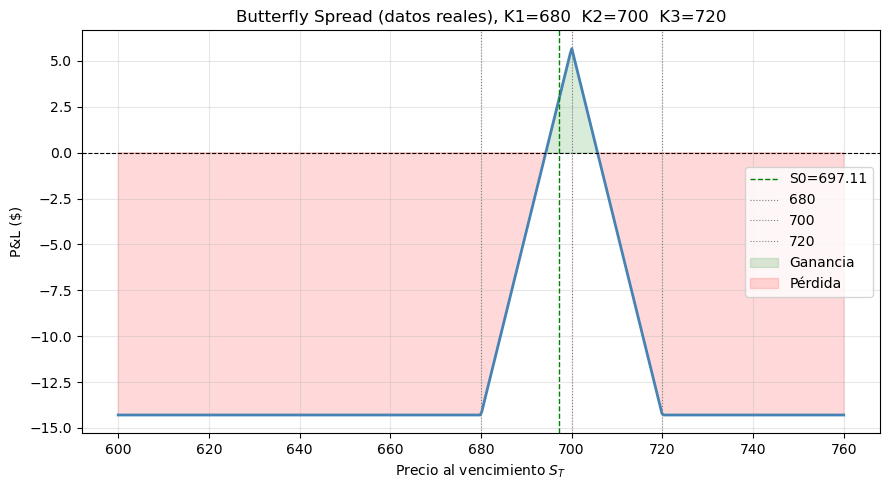

In [9]:
S_range = np.linspace(600, 760, 500)

# Butterfly con datos reales
legs_butterfly = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -2},
    {'tipo': 'call', 'K': K3, 'prima': C3, 'posicion': +1},
]

pnl = payoff_estrategia(S_range, legs_butterfly)

# Métricas
prima_neta = C1 - 2*C2 + C3

print(f"Prima neta pagada : ${prima_neta:.2f}")
print(f"Ganancia máxima   : ${(K2-K1)-prima_neta:.2f}  (si ST ={K2})")
print(f"Pérdida máxima    : ${-prima_neta:.2f}")
print(f"Break-even inf.   : ${K1+prima_neta:.2f}  |  sup.: ${K3-prima_neta:.2f}")

# Gráfica
graficar_estrategia(
    S_range, pnl,
    f'Butterfly Spread (datos reales), K1={K1}  K2={K2}  K3={K3}',
    S0=S0,
    K_lines=[(K1,f'{K1}'),(K2,f'{K2}'),(K3,f'{K3}')]
)

## **Iron Condor (payoff + métricas)**

Prima cobrada     : $0.32  (ganancia máxima)
Pérdida máxima    : $19.68
Zona de ganancia  : [680,720]


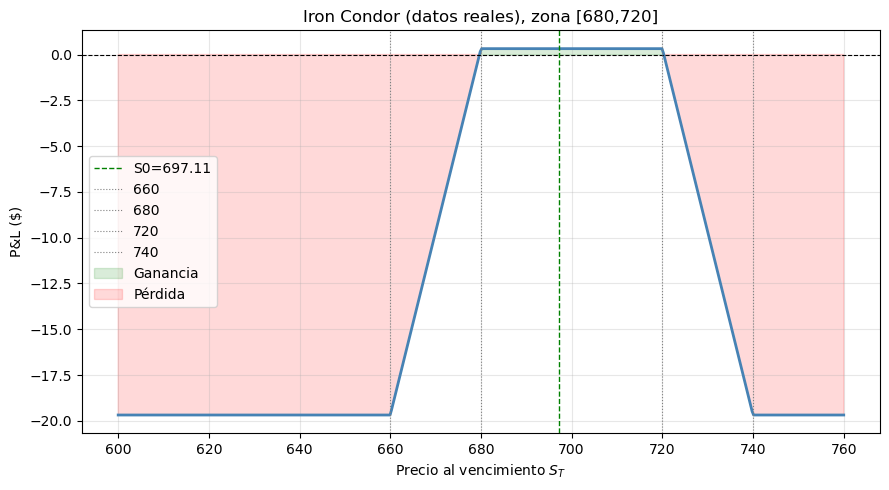

In [10]:
# Iron Condor
legs_condor = [
    {'tipo': 'put',  'K': K_pl, 'prima': P_l, 'posicion': +1},
    {'tipo': 'put',  'K': K_ps, 'prima': P_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cs, 'prima': C_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cl, 'prima': C_l, 'posicion': +1},
]

pnl = payoff_estrategia(S_range, legs_condor)

# Métricas
prima_cobrada = (P_s - P_l) + (C_s - C_l)
perdida_max   = (K_ps - K_pl) - prima_cobrada

print(f"Prima cobrada     : ${prima_cobrada:.2f}  (ganancia máxima)")
print(f"Pérdida máxima    : ${perdida_max:.2f}")
print(f"Zona de ganancia  : [{K_ps},{K_cs}]")

# Gráfica
graficar_estrategia(
    S_range, pnl,
    f'Iron Condor (datos reales), zona [{K_ps},{K_cs}]',
    S0=S0,
    K_lines=[(K_pl,f'{K_pl}'),(K_ps,f'{K_ps}'),
             (K_cs,f'{K_cs}'),(K_cl,f'{K_cl}')]
)

## **Covered Call (payoff + métricas)**

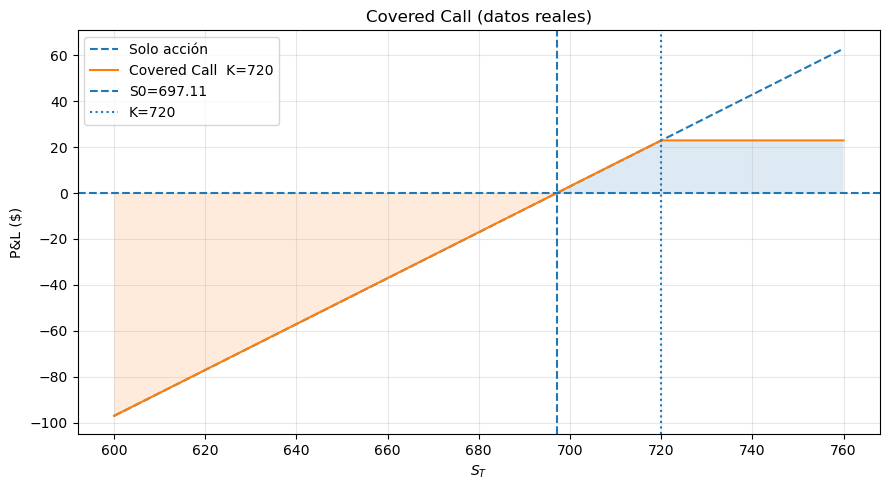

Ganancia máxima : $22.94  (si ST ≥720)
Break-even      : $697.06


In [11]:
import matplotlib.pyplot as plt

# Covered Call
pnl_accion  = S_range - S0
pnl_covered = pnl_accion + (-np.maximum(S_range - K_cc, 0) + C_cc)

plt.figure(figsize=(9, 5))
plt.plot(S_range, pnl_accion,  linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_covered, label=f'Covered Call  K={K_cc}')
plt.axhline(0, linestyle='--')
plt.axvline(S0, linestyle='--', label=f'S0={S0:.2f}')
plt.axvline(K_cc, linestyle=':', label=f'K={K_cc}')
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered>0), alpha=0.15)
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered<0), alpha=0.15)
plt.xlabel('$S_T$'); plt.ylabel('P&L ($)')
plt.title('Covered Call (datos reales)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Métricas
print(f"Ganancia máxima : ${K_cc - S0 + C_cc:.2f}  (si ST ≥{K_cc})")
print(f"Break-even      : ${S0 - C_cc:.2f}")

## **Protective Put (payoff + métricas)**

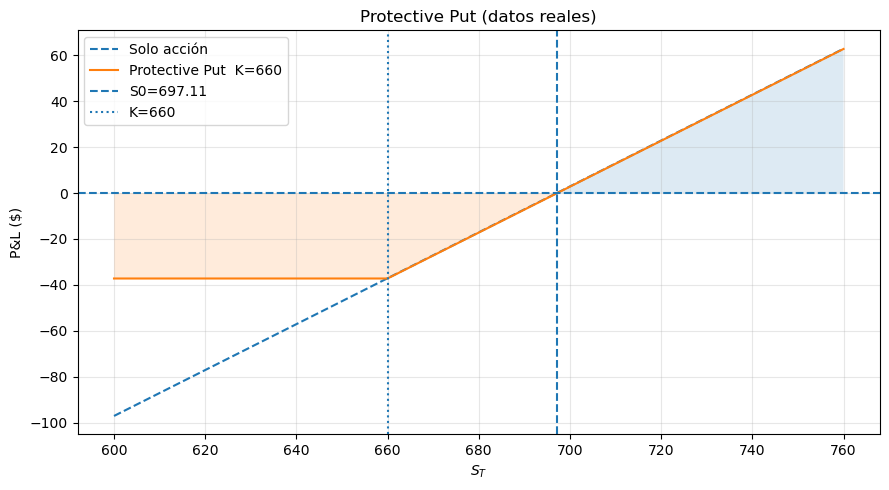

Pérdida máxima : $-37.22  (si ST ≤660)
Break-even     : $697.22


In [12]:
# Protective Put
pnl_protective = pnl_accion + (np.maximum(K_pp - S_range, 0) - P_pp)

plt.figure(figsize=(9, 5))
plt.plot(S_range, pnl_accion, linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_protective, label=f'Protective Put  K={K_pp}')
plt.axhline(0, linestyle='--')
plt.axvline(S0, linestyle='--', label=f'S0={S0:.2f}')
plt.axvline(K_pp, linestyle=':', label=f'K={K_pp}')
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective>0), alpha=0.15)
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective<0), alpha=0.15)
plt.xlabel('$S_T$'); plt.ylabel('P&L ($)')
plt.title('Protective Put (datos reales)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Métricas
print(f"Pérdida máxima : ${-(S0 - K_pp + P_pp):.2f}  (si ST ≤{K_pp})")
print(f"Break-even     : ${S0 + P_pp:.2f}")

### **Tabla resumen**

| Estrategia     | Prima neta   | Ganancia máxima    | Pérdida máxima        | Break-even(s)   |
| -------------- | ------------ | ------------------ | --------------------- | --------------- |
| Butterfly      | 14.29 pagada | 5.71               | -14.29                | 694.29 / 705.71 |
| Iron Condor    | 0.32 cobrada | 0.32               | 19.68                 | [680, 720]      |
| Covered Call   | 0.05 cobrada | 22.94              | Downside (S0 - prima) | 697.06          |
| Protective Put | 0.12 pagada  | Ilimitada (upside) | -37.22                | 697.22          |


# **PREGUNTAS**

**1. Con el S0 actual, ¿cuál de las cuatro estrategias está mejor posicionada (más cerca de su zona de máxima ganancia)? ¿Qué visión de mercado tendría que tener un trader para elegirla hoy?**

Con el S0 actual de 697.11, la estrategia mejor posicionada es el butterfly spread, ya que su punto de máxima ganancia está en K2 = 700, que se encuentra muy cerca del precio actual. Además, sus break-even (694.29 y 705.71) encierran al S0, lo que indica que actualmente está dentro de su zona de ganancia.

Un trader que elegiría esta estrategia tendría una visión de mercado muy específica: esperaría que SPY termine muy cerca de 700 al vencimiento. Es una apuesta de alta precisión donde se busca que el precio se mantenga prácticamente sin movimiento alrededor de un nivel concreto.


**2. Un iron condor cobra prima desde el inicio. ¿Eso lo hace una estrategia sin riesgo? ¿Cuál es el peor escenario para tu condor y cuándo ocurre? Calcula la pérdida máxima exacta con tus datos.**

No, el hecho de que un iron condor cobre prima desde el inicio no significa que sea una estrategia sin riesgo. La prima es la compensación por asumir el riesgo de que el precio del subyacente se mueva fuera del rango esperado.

El peor escenario ocurre cuando SPY se mueve fuertemente hacia arriba o hacia abajo y sale del rango de ganancia [680, 720]. En ese caso, la estrategia alcanza su pérdida máxima.

Con mis datos, la pérdida máxima exacta es de 19.68, y ocurre cuando el precio cae por debajo de 660 o sube por encima de 740, es decir, cuando alguno de los spreads se va completamente “in the money”.


**3. Si la IV de SPY estuviera en 35% (muy alta), ¿preferirías comprar un straddle (clase pasada) o vender un iron condor? Justifica tu respuesta en términos de vega y theta.**

Si la volatilidad implícita (IV) de SPY estuviera en 35%, preferiría vender un iron condor en lugar de comprar un straddle. Esto se debe a que el iron condor tiene vega negativa y theta positiva, lo que significa que se beneficia de una caída en la volatilidad y del paso del tiempo.

Cuando la IV es alta, las primas están infladas, por lo que vender opciones permite capturar ese valor elevado. En cambio, un straddle tiene vega positiva, por lo que perdería valor si la volatilidad baja, además de tener theta negativa, lo que implica pérdida de valor con el paso del tiempo.

Por lo tanto, en un entorno de alta IV, vender volatilidad mediante un iron condor es más favorable.


**4. El covered call limita la ganancia por encima de K. ¿Por qué un inversionista de largo plazo estaría dispuesto a aceptar ese límite voluntariamente? Da al menos dos razones concretas.**

Un inversionista de largo plazo estaría dispuesto a aceptar el límite en la ganancia de un covered call por varias razones.

Primero, porque le permite generar ingresos adicionales de forma constante a través de la prima, lo que reduce el costo efectivo de su inversión. Segundo, porque si está dispuesto a vender sus acciones a cierto precio (K), entonces no le afecta limitar el upside más allá de ese nivel.

En esencia, el inversionista intercambia parte del potencial de ganancia futura por ingresos presentes más seguros y recurrentes.


**5. Compara el protective put con un seguro de auto. ¿Cuáles son las analogías que funcionan bien? ¿Dónde se rompe la analogía? Piensa en términos de costo, duración, deducible y qué pasa cuando "no usas el seguro".**

El protective put es muy similar a un seguro de auto en varios aspectos. En ambos casos, se paga una prima para protegerse contra un evento adverso: en el mercado, una caída del precio; en el auto, un accidente. También existe un “piso” de protección, equivalente al deducible, que en este caso es el strike del put.

Sin embargo, la analogía se rompe en algunos puntos. A diferencia de un seguro tradicional, el protective put tiene un vencimiento definido, por lo que la protección solo dura cierto tiempo. Además, si el evento adverso no ocurre, la prima pagada se pierde completamente, sin ningún beneficio directo, similar a un seguro no utilizado.

Otra diferencia es que el valor del “seguro” (la opción) cambia constantemente con el mercado, mientras que un seguro de auto tiene un costo más estable.


**6. ¿En qué se diferencia el butterfly del iron condor en términos de cuándo cada uno es más apropiado? ¿Cuál de los dos requiere mayor precisión en tu pronóstico sobre dónde estará SPY al vencimiento? Apóyate en el ancho de la zona de ganancia que observas en tus gráficas.**

El butterfly y el iron condor se diferencian principalmente en el ancho de su zona de ganancia. El butterfly tiene una zona de ganancia muy estrecha, concentrada alrededor de un punto específico (K2 = 700), mientras que el iron condor tiene una zona mucho más amplia, entre 680 y 720.

Por esta razón, el butterfly requiere mayor precisión en el pronóstico, ya que la ganancia máxima solo se obtiene si el precio termina muy cerca de un nivel específico. En cambio, el iron condor es más flexible, ya que permite que el precio se mueva dentro de un rango amplio sin generar pérdidas.

En mis gráficas se observa claramente que el condor tiene una “meseta” amplia de ganancia, mientras que el butterfly tiene un pico muy pronunciado.


**7. Tanto el butterfly como el iron condor tienen vega negativa. Si compras un butterfly hoy y mañana la IV cae 5 puntos sin que SPY se mueva, ¿qué le pasa al valor de tu posición? ¿Por qué?**

Si compro un butterfly hoy y mañana la IV cae 5 puntos sin que SPY se mueva, el valor de mi posición disminuirá. Esto se debe a que el butterfly tiene vega negativa.

Al caer la volatilidad implícita, el valor de las opciones disminuye, lo que afecta negativamente a la estrategia en su conjunto. Aunque el paso del tiempo (theta positiva) favorece al butterfly, una caída en la IV reduce el valor de la posición en el corto plazo.

Esto refleja que, aunque es una estrategia neutral, sigue estando expuesta a cambios en la volatilidad.